In [1]:
import pandas as pd

Export .csv are survey results downloaded directly from PostHog

In [2]:
df = pd.read_csv('./export-2026-07-22-141104.csv')
df.shape

(39, 112)

In [3]:
df.columns.tolist()

['*.uuid',
 '*.event',
 '*.properties.$insert_id',
 '*.properties.$os',
 '*.properties.$raw_user_agent',
 '*.properties.$browser_language_prefix',
 '*.properties.$last_posthog_reset',
 '*.properties.$browser',
 '*.properties.models.0',
 '*.properties.models.1',
 '*.properties.$time',
 '*.properties.$referrer',
 '*.properties.$survey_id',
 '*.properties.$survey_response_cf88935b-32e0-4db3-9cea-aa2f178a9656',
 '*.properties.$session_entry_url',
 '*.properties.$pageview_id',
 '*.properties.$feature/survey-targeting-52f93e9341-custom',
 '*.properties.$sdk_dist_channel',
 '*.properties.$survey_iteration_start_date',
 '*.properties.$survey_response_f1248e20-e2d7-4ec7-a8a3-628403ef853b',
 '*.properties.$browser_version',
 '*.properties.$timezone_offset',
 '*.properties.$referring_domain',
 '*.properties.$session_entry_pathname',
 '*.properties.$recording_status',
 '*.properties.$survey_response_cf16c5b3-416a-4a3d-b307-07ddcce18f3f',
 '*.properties.$session_entry_referring_domain',
 '*.propert

In [4]:
[c for c in df.columns if "survey_completed" in c]

['*.properties.$survey_completed']

In [5]:
fr_df = pd.read_csv('export-2026-07-22-141154.csv')
fr_df.shape

(8, 102)

In [6]:
rel_columns = ['timestamp', 
               '*.properties.$survey_completed',
               '*.properties.search_query',
               '*.properties.locale',
               '*.properties.models.0',
               '*.properties.models.1',
               '*.properties.$survey_questions.0.response',
               '*.properties.$survey_questions.1.response',
               '*.properties.$survey_questions.2.response',
               '*.properties.$survey_questions.3.response',
            ]
 
df[rel_columns].head()

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response
0,2026-07-22 14:09:09.847000+00:00,True,endangered species,en,semantic_search,semantic_search_new,English,They are equally good,6th,none
1,2026-07-22 14:05:46.492000+00:00,True,Qualité de l’eau du Lake Superior,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,2nd,5th
2,2026-07-22 14:03:31.944000+00:00,True,lake superior water quality,en,semantic_search,semantic_search_new,English,They are equally good,1st,1st
3,2026-07-22 14:00:24.491000+00:00,True,hauteur de la montagne Rocheuses,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,none
4,2026-07-22 13:56:30.198000+00:00,True,mountain height rockies,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none


In [7]:
fr_df[rel_columns]

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response
0,2026-07-15 18:29:10.125000+00:00,True,mnehr,fr,keyword_search,semantic_search_new,En français,Résultats de la Recherche par Mot-clé,Plus de 10e,plus de 10e
1,2026-07-15 18:26:04.946000+00:00,True,lidar,fr,keyword_search,semantic_search,En français,Résultats de la Recherche par Mot-clé,au delà de 10e,4ème
2,2026-07-15 13:22:38.467000+00:00,True,feux de forêts en Colombie-Britanique,fr,semantic_search,semantic_search_new,En français,Résultats de la Recherche Sémantique *Nouveau*,2ème,2ème
3,2026-07-14 19:23:25.505000+00:00,True,bassins versants canada,fr,semantic_search,semantic_search_new,En français,Résultats de la Recherche Sémantique *Nouveau*,It's probably more an issue of the description...,same comment then recherche sémantique nouveau.
4,2026-07-14 18:25:54.502000+00:00,True,élévation canada,fr,semantic_search,semantic_search_new,En français,Résultats de la Recherche Sémantique,6,1er
5,2026-07-14 18:24:10.705000+00:00,True,élévation canada,fr,keyword_search,semantic_search,En français,Résultats de la Recherche Sémantique,j'ai juste comparé recherche sémantique et key...,1er
6,2026-07-14 18:05:59.394000+00:00,False,inondations,fr,semantic_search,semantic_search_new,En français,Résultats de la Recherche Sémantique *Nouveau*,NaN,NaN
7,2026-07-14 17:28:12.956000+00:00,True,aires marine protégées,fr,semantic_search,semantic_search_new,En français,Résultats de la Recherche Sémantique,2ème,1er


In [8]:
combined_df = pd.concat([df[rel_columns], fr_df[rel_columns]], axis=0)
combined_df.shape

(47, 10)

In [9]:
# standardize column values
col2mapping = {
    '*.properties.$survey_questions.0.response': {
        'En français': 'French',
        'En anglais': 'English'
    },
    '*.properties.$survey_questions.1.response': {
        'Résultats de la Recherche par Mot-clé': 'Keyword Search results',
        'Résultats de la Recherche Sémantique': 'Semantic Search results',
        'Résultats de la  Recherche Sémantique *Nouveau*': 'Semantic Search *New* results',
        'Ils sont tout aussi bons': 'They are equally good',
        'Ils sont tout aussi mauvais': 'They are equally bad',
    }
}

combined_df = combined_df.replace(col2mapping)
combined_df

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response
0,2026-07-22 14:09:09.847000+00:00,True,endangered species,en,semantic_search,semantic_search_new,English,They are equally good,6th,none
1,2026-07-22 14:05:46.492000+00:00,True,Qualité de l’eau du Lake Superior,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,2nd,5th
2,2026-07-22 14:03:31.944000+00:00,True,lake superior water quality,en,semantic_search,semantic_search_new,English,They are equally good,1st,1st
3,2026-07-22 14:00:24.491000+00:00,True,hauteur de la montagne Rocheuses,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,none
4,2026-07-22 13:56:30.198000+00:00,True,mountain height rockies,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none
5,2026-07-22 13:53:04.704000+00:00,True,Avertissements de tornade,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,4th
6,2026-07-22 13:51:54.852000+00:00,True,tornado warnings,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,1st
7,2026-07-22 13:37:22.655000+00:00,True,no logging alberta,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none
8,2026-07-14 18:56:26.721000+00:00,True,boundary,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,1st
9,2026-07-14 18:49:25.921000+00:00,False,deer,en,keyword_search,semantic_search,English,NaN,NaN,NaN


In [10]:
df_subset = combined_df.copy()

# restrict by timestamp
df_subset = df_subset[df_subset['timestamp'] >= '2026-07-09 00:00:00']
print(f"Restricting by timestamp: {df_subset.shape[0]} rows remaining")

# restrict surveys to only include ones comparing semantic searches
df_subset = df_subset[df_subset['*.properties.models.0'].str.contains('semantic') & df_subset['*.properties.models.1'].str.contains('semantic')]
print(f"Restricting to semantic search surveys: {df_subset.shape[0]} rows remaining")

df_subset.info()

Restricting by timestamp: 47 rows remaining
Restricting to semantic search surveys: 28 rows remaining
<class 'pandas.DataFrame'>
Index: 28 entries, 0 to 7
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   timestamp                                  28 non-null     str  
 1   *.properties.$survey_completed             28 non-null     bool 
 2   *.properties.search_query                  28 non-null     str  
 3   *.properties.locale                        28 non-null     str  
 4   *.properties.models.0                      28 non-null     str  
 5   *.properties.models.1                      28 non-null     str  
 6   *.properties.$survey_questions.0.response  28 non-null     str  
 7   *.properties.$survey_questions.1.response  26 non-null     str  
 8   *.properties.$survey_questions.2.response  24 non-null     str  
 9   *.properties.$survey_questions.3.resp

In [11]:
df_subset['*.properties.search_query'].value_counts()

*.properties.search_query
forest fires                             2
Feux de forêt                            2
endangered species                       1
Qualité de l’eau du Lake Superior        1
lake superior water quality              1
hauteur de la montagne Rocheuses         1
mountain height rockies                  1
Avertissements de tornade                1
tornado warnings                         1
no logging alberta                       1
boundary                                 1
land cover canada                        1
land use canada                          1
airborne radioactivity                   1
forest fires quebec                      1
radioactivité environnementale           1
Bow river                                1
Forest logging near Canmore Alberta      1
alberta flood maps                       1
flood inundation maps                    1
Earthquakes in Canada                    1
feux de forêts en Colombie-Britanique    1
bassins versants canada     

In [12]:
df_subset

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response
0,2026-07-22 14:09:09.847000+00:00,True,endangered species,en,semantic_search,semantic_search_new,English,They are equally good,6th,none
1,2026-07-22 14:05:46.492000+00:00,True,Qualité de l’eau du Lake Superior,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,2nd,5th
2,2026-07-22 14:03:31.944000+00:00,True,lake superior water quality,en,semantic_search,semantic_search_new,English,They are equally good,1st,1st
3,2026-07-22 14:00:24.491000+00:00,True,hauteur de la montagne Rocheuses,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,none
4,2026-07-22 13:56:30.198000+00:00,True,mountain height rockies,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none
5,2026-07-22 13:53:04.704000+00:00,True,Avertissements de tornade,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,4th
6,2026-07-22 13:51:54.852000+00:00,True,tornado warnings,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,1st
7,2026-07-22 13:37:22.655000+00:00,True,no logging alberta,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none
8,2026-07-14 18:56:26.721000+00:00,True,boundary,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,1st
10,2026-07-14 18:18:09.425000+00:00,True,land cover canada,en,semantic_search,semantic_search_new,English,They are equally good,3rd,3rd


# Preference

In [13]:
df_subset.shape

(28, 10)

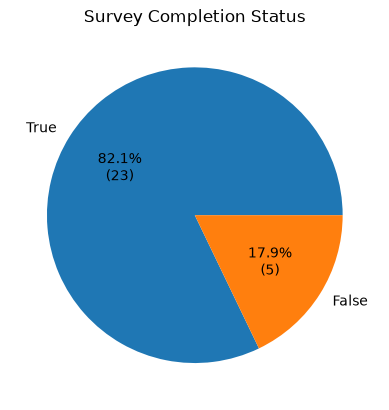

In [14]:
import matplotlib.pyplot as plt
import numpy as np

survey_completes = df_subset["*.properties.$survey_completed"].value_counts()
def absolute_and_percentage(pct):
    total = sum(survey_completes)
    val = int(round(pct / 100.0 * total))
    return f'{pct:.1f}%\n({val})'

plt.pie(survey_completes, labels=survey_completes.index, autopct=absolute_and_percentage)
plt.title("Survey Completion Status")
plt.show()

In [15]:
df_subset_completed_only = df_subset[df_subset['*.properties.$survey_completed'] == True]
df_subset_completed_only.shape

(23, 10)

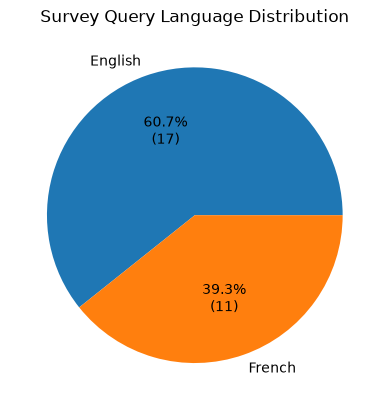

In [16]:
survey_query_langs = df_subset["*.properties.$survey_questions.0.response"].value_counts()
def absolute_and_percentage(pct):
    total = sum(survey_query_langs)
    val = int(round(pct / 100.0 * total))
    return f'{pct:.1f}%\n({val})'

plt.pie(survey_query_langs, labels=survey_query_langs.index, autopct=absolute_and_percentage)
plt.title("Survey Query Language Distribution")
plt.show()

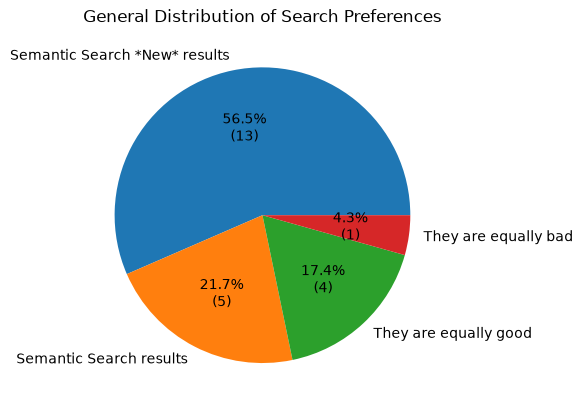

In [17]:
search_pref_counts = df_subset_completed_only["*.properties.$survey_questions.1.response"].value_counts()
def absolute_and_percentage(pct):
    total = sum(search_pref_counts)
    val = int(round(pct / 100.0 * total))
    return f'{pct:.1f}%\n({val})'


plt.pie(search_pref_counts, labels=search_pref_counts.index, autopct=absolute_and_percentage)
plt.title("General Distribution of Search Preferences")
plt.show()

In [18]:
df_subset_completed_only[df_subset_completed_only["*.properties.$survey_questions.1.response"].str.contains("bad")]

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response
16,2026-07-14 17:23:40.362000+00:00,True,Bow river,en,semantic_search,semantic_search_new,English,They are equally bad,NaN,NaN


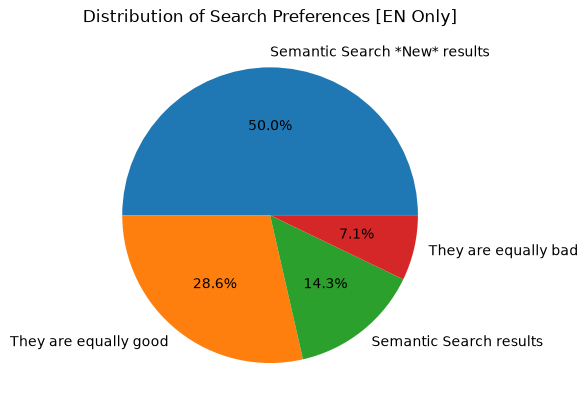

In [19]:
df_subset_en = df_subset_completed_only[df_subset_completed_only['*.properties.$survey_questions.0.response'] == 'English']

plt.pie(df_subset_en["*.properties.$survey_questions.1.response"].value_counts(), labels=df_subset_en["*.properties.$survey_questions.1.response"].value_counts().index, autopct='%1.1f%%')
plt.title("Distribution of Search Preferences [EN Only]")
plt.show()

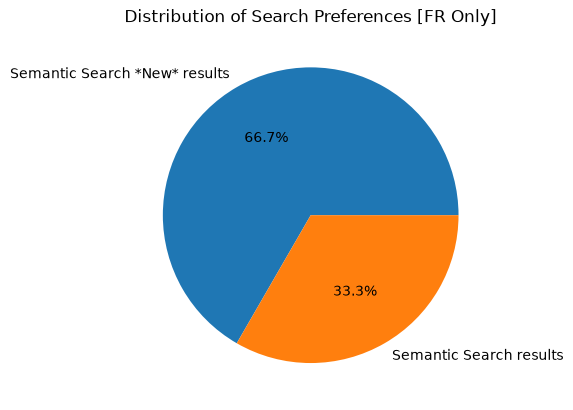

In [20]:
df_subset_fr = df_subset_completed_only[df_subset_completed_only['*.properties.$survey_questions.0.response'] == 'French']

plt.pie(df_subset_fr["*.properties.$survey_questions.1.response"].value_counts(), labels=df_subset_fr["*.properties.$survey_questions.1.response"].value_counts().index, autopct='%1.1f%%')
plt.title("Distribution of Search Preferences [FR Only]")
plt.show()

# Statistics for Semantic Search

In [21]:
import re

def extract_position(x):
    match = re.match(r'^\d+', str(x))
    if match:
        return int(match.group())
    else:
        return 0 # invalid rank

def compute_mrr(df, position_col):
    """
    Computes the Mean Reciprocal Rank (MRR) for a given DataFrame and position column.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the position data.
    position_col (str): The name of the column containing the position of the most relevant document.
    
    Returns:
    float: The computed MRR value.
    """
    if len(df) == 0:
        return 0.0
    
    # Calculate reciprocal ranks
    df['reciprocal_rank'] = df[position_col].apply(lambda x: 1/x if x > 0 else 0)
    
    # Compute MRR
    mrr = df['reciprocal_rank'].mean()
    
    return mrr

def compute_recall_at_3(df, position_col):
    """
    Computes the Recall@3 for a given DataFrame and position column.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the position data.
    position_col (str): The name of the column containing the position of the most relevant document.
    
    Returns:
    float: The computed Recall@3 value.
    """
    if len(df) == 0:
        return 0.0

    # Count how many times the most relevant document is in the top 3
    recall_count = df[position_col].apply(lambda x: 1 if x > 0 and x <= 3 else 0).sum()
    
    # Compute Recall@3
    recall_at_3 = recall_count / len(df)
    
    return recall_at_3



def compute_statistics(df, position_col):
    semsearch_results = {}

    semsearch_results['mrr@10'] = {
        'overall': compute_mrr(df, position_col),
        'en': compute_mrr(df[df['*.properties.$survey_questions.0.response'] == 'English'], position_col),
        'fr': compute_mrr(df[df['*.properties.$survey_questions.0.response'] == 'French'], position_col),
    }

    semsearch_results['recall@3'] = {
        'overall': compute_recall_at_3(df, position_col),
        'en': compute_recall_at_3(df[df['*.properties.$survey_questions.0.response'] == 'English'], position_col),
        'fr': compute_recall_at_3(df[df['*.properties.$survey_questions.0.response'] == 'French'], position_col),
    }

    return semsearch_results
    

In [22]:
df_subset_sem_old = df_subset_completed_only.copy()
df_subset_sem_old = df_subset_sem_old[~df_subset_sem_old['*.properties.$survey_questions.3.response'].isna()]
df_subset_sem_old.shape

(22, 10)

In [23]:
df_subset_sem_old['most_relevant_doc_location_old'] = df_subset_sem_old['*.properties.$survey_questions.3.response'].apply(extract_position)
df_subset_sem_old

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response,most_relevant_doc_location_old
0,2026-07-22 14:09:09.847000+00:00,True,endangered species,en,semantic_search,semantic_search_new,English,They are equally good,6th,none,0
1,2026-07-22 14:05:46.492000+00:00,True,Qualité de l’eau du Lake Superior,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,2nd,5th,5
2,2026-07-22 14:03:31.944000+00:00,True,lake superior water quality,en,semantic_search,semantic_search_new,English,They are equally good,1st,1st,1
3,2026-07-22 14:00:24.491000+00:00,True,hauteur de la montagne Rocheuses,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,none,0
4,2026-07-22 13:56:30.198000+00:00,True,mountain height rockies,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none,0
5,2026-07-22 13:53:04.704000+00:00,True,Avertissements de tornade,en,semantic_search,semantic_search_new,French,Semantic Search *New* results,1st,4th,4
6,2026-07-22 13:51:54.852000+00:00,True,tornado warnings,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,1st,1
7,2026-07-22 13:37:22.655000+00:00,True,no logging alberta,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,none,0
8,2026-07-14 18:56:26.721000+00:00,True,boundary,en,semantic_search,semantic_search_new,English,Semantic Search *New* results,1st,1st,1
10,2026-07-14 18:18:09.425000+00:00,True,land cover canada,en,semantic_search,semantic_search_new,English,They are equally good,3rd,3rd,3


In [24]:
old_stats = compute_statistics(df_subset_sem_old, 'most_relevant_doc_location_old')
old_stats

{'mrr@10': {'overall': np.float64(0.40737734487734484),
  'en': np.float64(0.3855616605616605),
  'fr': np.float64(0.4388888888888889)},
 'recall@3': {'overall': np.float64(0.4090909090909091),
  'en': np.float64(0.38461538461538464),
  'fr': np.float64(0.4444444444444444)}}

In [25]:
# new semsearch results
df_subset_sem_new = df_subset_completed_only.copy()
df_subset_sem_new = df_subset_sem_new[~df_subset_sem_new['*.properties.$survey_questions.2.response'].isna()]
df_subset_sem_new['most_relevant_doc_location_new'] = df_subset_sem_new['*.properties.$survey_questions.2.response'].apply(extract_position)
df_subset_sem_new.shape

(22, 11)

In [26]:
new_stats = compute_statistics(df_subset_sem_new, 'most_relevant_doc_location_new')
new_stats

{'mrr@10': {'overall': np.float64(0.6287878787878788),
  'en': np.float64(0.6794871794871794),
  'fr': np.float64(0.5555555555555556)},
 'recall@3': {'overall': np.float64(0.7727272727272727),
  'en': np.float64(0.7692307692307693),
  'fr': np.float64(0.7777777777777778)}}

## Plot

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(metrics, old_scores, new_scores, title="MRR and Recall@3 Comparison"):
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(x - width/2, old_scores, width, label="Old Search")
    bars2 = ax.bar(x + width/2, new_scores, width, label="New Search")

    # Add value labels above bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom"
            )

    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0, max(max(old_scores), max(new_scores)) * 1.15)

    plt.tight_layout()
    plt.show()

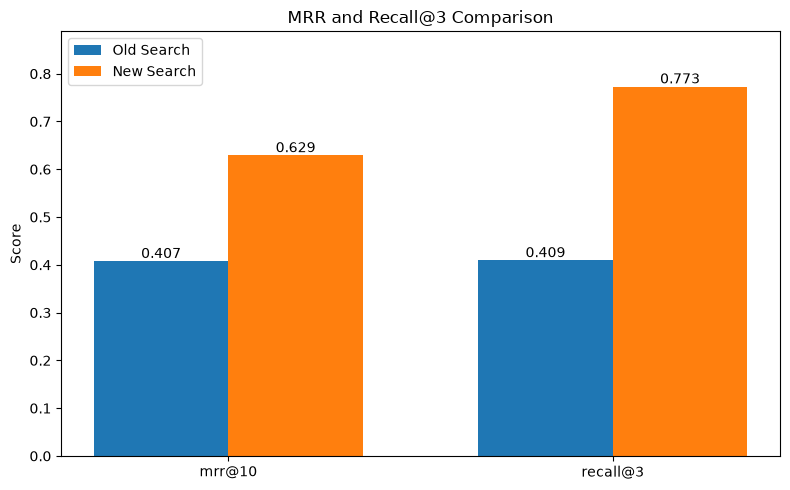

In [28]:
metrics = ["mrr@10", "recall@3"]

old_scores = [old_stats[m]['overall'] for m in metrics]
new_scores = [new_stats[m]['overall'] for m in metrics]

plot_comparison(metrics, old_scores, new_scores, title="MRR and Recall@3 Comparison")

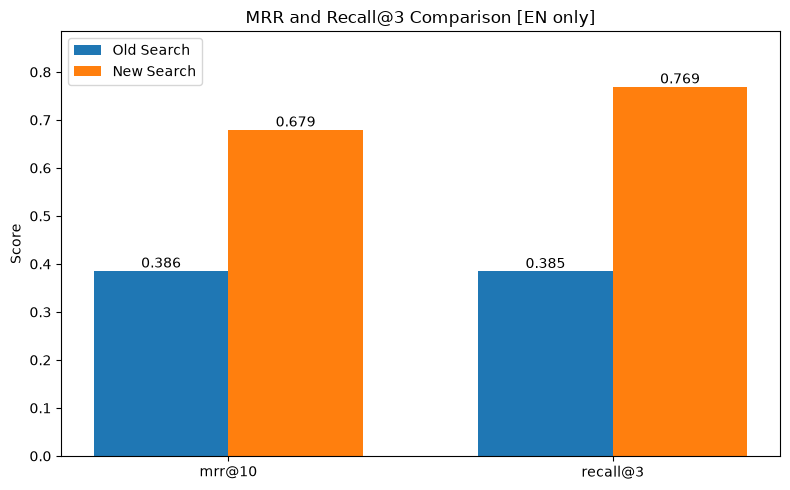

In [29]:
metrics = ["mrr@10", "recall@3"]

old_scores = [old_stats[m]['en'] for m in metrics]
new_scores = [new_stats[m]['en'] for m in metrics]

plot_comparison(metrics, old_scores, new_scores, title="MRR and Recall@3 Comparison [EN only]")

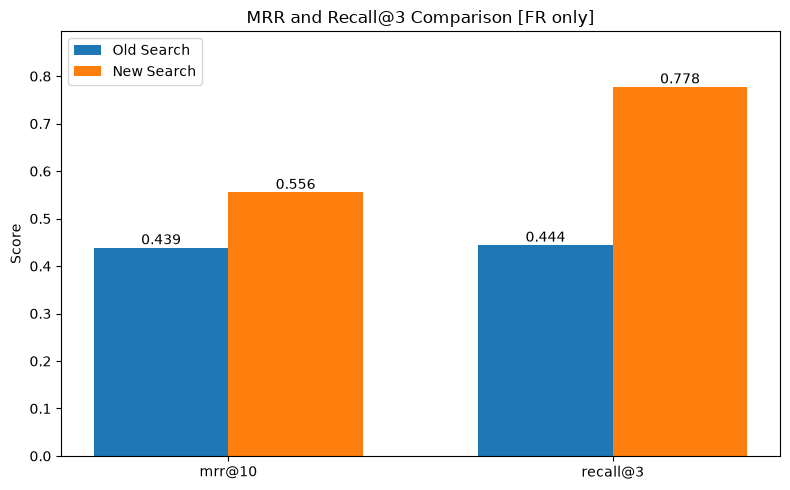

In [30]:
metrics = ["mrr@10", "recall@3"]

old_scores = [old_stats[m]['fr'] for m in metrics]
new_scores = [new_stats[m]['fr'] for m in metrics]

plot_comparison(metrics, old_scores, new_scores, title="MRR and Recall@3 Comparison [FR only]")

# Qualitative Analysis

In [31]:
# for what queries do we prefer the old semantic search results over the new semantic search results?
df_subset[df_subset['*.properties.$survey_questions.1.response'] == 'Semantic Search results']

,timestamp,*.properties.$survey_completed,*.properties.search_query,*.properties.locale,*.properties.models.0,*.properties.models.1,*.properties.$survey_questions.0.response,*.properties.$survey_questions.1.response,*.properties.$survey_questions.2.response,*.properties.$survey_questions.3.response
14,2026-07-14 18:10:07.583000+00:00,True,radioactivité environnementale,en,semantic_search,semantic_search_new,French,Semantic Search results,1st,1st
17,2026-07-14 17:14:56.691000+00:00,True,Forest logging near Canmore Alberta,en,semantic_search,semantic_search_new,English,Semantic Search results,none,10
25,2026-07-13 19:00:50.645000+00:00,True,flood inundation maps,en,semantic_search,semantic_search_new,English,Semantic Search results,none,9th
4,2026-07-14 18:25:54.502000+00:00,True,élévation canada,fr,semantic_search,semantic_search_new,French,Semantic Search results,6,1er
7,2026-07-14 17:28:12.956000+00:00,True,aires marine protégées,fr,semantic_search,semantic_search_new,French,Semantic Search results,2ème,1er


Why did the new model struggle so much with elevation? Training queries were not great..


// This is fine
>>> df[(df['features_properties_title_en'].str.contains('Elevation')) & (~df['features_properties_title_en'].str.contains('STAC'))][['features_properties_title_en', 'query_en', 'query_fr']][20:25]
                                                             features_properties_title_en  \
1114  Hanmore Lake, Alberta - Bathymetry, Digital Elevation Model (Arc ASCII grid format)
1139  Buffalo Lake, Alberta - Bathymetry, Digital Elevation Model (Arc ASCII grid format)
1183  Bridge Lakes, Alberta - Bathymetry, Digital Elevation Model (Arc ASCII grid format)
1257  Millers Lake, Alberta - Bathymetry, Digital Elevation Model (Arc ASCII grid format)
1294  Laurier Lake, Alberta - Bathymetry, Digital Elevation Model (Arc ASCII grid format)

                                          query_en  \
1114       how is the water bathymetric in hanmore
1139                                  buffalo lake
1183                   lake bathymetric in alberta
1257  average elevation in millers lake in alberta
1294                                  laurier lake

                                                               query_fr
1114                                              où est le lac hanmore
1139                quelle est la grille actuelle du lac bufalo alberta
1183                                         qu'est-ce que bridge lakes
1257           dans quelle direction est la mathématique de bathymétrie
1294  comment s'appelle la grille de l'élévation de lac laurier alberta


// Queries are not informative
>>> df[df['features_properties_title_en'].str.contains('Elevation')][['features_properties_title_en', 'query_en', 'query_fr']][10:15]
                                                                                                            features_properties_title_en  \
88              STAC-Item - NS Indian Brook 2m - Mosaic of High Resolution Digital Elevation Model (HRDEM) by LiDAR acquisition project
91         STAC-Item - NWT Tuktoyaktuk 2020 1m - Mosaic of High Resolution Digital Elevation Model (HRDEM) by LiDAR acquisition project
97                 STAC-Item - YT Mayo 2021 1m - Mosaic of High Resolution Digital Elevation Model (HRDEM) by LiDAR acquisition project
100  STAC-Item - CLOCA South Central Durham 1m - Mosaic of High Resolution Digital Elevation Model (HRDEM) by LiDAR acquisition project
109    STAC-Item - NRCAN Jasper Park 2019 2 1m - Mosaic of High Resolution Digital Elevation Model (HRDEM) by LiDAR acquisition project

         query_en                         query_fr
88      stac data        qu'est-ce que l'item stac
91      stac data           qu'est-ce qu'un mnenhr
97   stac dataset             qu'est-ce qu'un mnhr
100          stac  qu'est-ce que la mosaïque mnehr
109     stac data        que sont les données mnhr


// Queries focus a little too much on canvec and contours and not enough on the elevation...
>>> df[(df['features_properties_title_en'].str.contains('Elevation')) & (~df['features_properties_title_en'].str.contains('STAC')) & (~df['features_properties_title_en'].str.contains('Arc ASCII grid format'))][['features_properties_title_en
', 'query_en', 'query_fr']]
                                                                                                                                                                                                features_properties_title_en  \
48                                                                                                                                                                                    Forest Elevation(Ht) Covariance (2015)
271                                                                                                                                                                                                     Elevation by Ecozone
421                                                                                                                                                                               Alberta Provincial Digital Elevation Model
423                                                                                                                                                                        Ontario Digital Elevation Model (Imagery-Derived)
472                                                                                                                                                                                         Elevation Points - 250k - Canvec
795                                                                                                                                                                   Lotic Riparian - Digital Elevation Model (DEM) Derived
886                                                                                                                                                                                             Forest Elevation Mean (2022)
1703                                                                                                                                                                         Forest Elevation (Ht) Standard Deviation (2022)
2271                                                                                                                                                                 Mackenzie Valley Air Photo Digital Elevation Model Data
2648                                                                                                                                                                                         Elevation Points - 50k - Canvec
3113                                                                                                                                                                                                  Elevation by Ecoregion
3246                                                                                                                                                                                LiDAR Point Clouds - CanElevation Series
3334                                                                                                                                                                                     Lidar Digital Elevation Model (DEM)
3608                                                                                                                                                                                                 Index Contour Elevation
4282  Static-Water-Level Elevation Contours in the Grand Centre, Sand River, Ethel Lake and Muriel Lake Formations, and Empress Formation Unit 1 and 3 in the Cold Lake-Beaver River Drainage Basin (GIS data, line feature)
5374                                                                                                                   Pick Elevations for the Bedrock Topography of the Alberta Plains (tabular data, tab delimited format)
5493                                                                                                                                                   High Resolution Digital Elevation Model (HRDEM) - CanElevation Series
5532                                                                                                                                                                                            Ontario Elevation Data Index
6392                                                                                                                                                                                                Elevation by Ecodistrict
6450                                                                                                                                                                                      Forest Elevation Covariance (2022)
6664                                                                                                                                                                                        Forest Elevation(Ht) Mean (2015)
7244                                                                                                                                                         Digital Elevation Model for British Columbia - CDED - 1:250,000
7670                                                                                                                                                                                                               Elevation
7987                                                                                                                                     High Resolution Digital Elevation Model Mosaic (HRDEM Mosaic) - CanElevation Series
8632                                                                                                                                                                                                Elevation by Ecoprovince
8654                                                                                                                                                                             Forest 95th Percentile Elevation(Ht) (2015)
8712                                                                                                                                                                Elevation in Canada - CanVec Series - Elevation Features

                                                query_en  \
48               covariance of forest height measurement
271                                 elevation by ecozone
421                  how to find alberta elevation model
423                        an elevation model in ontario
472                                    canvec in contour
795   what kind of land type is in the riparian province
886                                     forest elevation
1703              an equivalent ht for forest management
2271                       where is the mackenzie valley
2648                                              canvec
3113                   ecological elevation by ecoregion
3246                                      lidar latitude
3334                                           dem model
3608                          an index contour in canada
4282              beaver river drainage basin in alberta
5374               what kind of topography is alberta in
5493                                               hrdem
5532                                      elevation data
6392                what causes a tree tree to be eleved
6450                 forest structural covariance canada
6664                      how to calculate forest height
7244                                    cdad in columbia
7670                                       nst elevation
7987                                         mosaic data
8632                            elevation by ecoprovince
8654                                      forests height
8712                                    canvec elevation

                                                                            query_fr
48                                coefficient de variation de la hauteur de la forêt
271                                         quelle altitude sont les zones d'écozone
421                                                     modèle de l'altitude alberta
423                                            qu'est-ce que le gestionnaire d'homme
472                                                  quelle est l'altitude de canvec
795                                                    que sont les zones riveraines
886                                  altitude moyenne de la forêt canadien pour 2022
1703                            qu'est-ce que l'écart type de l'altitude de la forêt
2271                         modèle altimétrique numérique de la vallée du mackenzie
2648                                                         qu'est-ce que la canvec
3113                                 quels sont les codes d'altitude par l'écorégion
3246                                         qu'est-ce qu'un fichier nuage de points
3334                                                   qu'est-ce que lidar numérique
3608                   quel est le texte défini pour l'élevation du contour d'indice
4282  quel état de l'alberta se trouve dans la région des castors de la gorge froide
5374                                              quelle est la surface de l'alberta
5493                                                              que signifie mnehr
5532                                    qu'est-ce qu'une donnée altimétrique ontario
6392        quelle est la différence entre l'altitude minimale et l'altitude moyenne
6450                                                covariance d'altitude forestière
6664                                                           qu'est-ce qu'un lidar
7244                                     quels sont les formats numériques pour cdad
7670                                                            mots-clés d'altitude
7987                                                 qu'est-ce que la mosaïque mnerr
8632                                                        c'est quoi l'écoprovince
8654                                                           qu'est-ce qu'un ntems
8712                                                              à quoi sert cantec

Next step: stricter quality control on synthetic queries

* Reduce over-use of question words, i.e. What does, qu'est-ce que
* Any reference to keywords/mots-clés should force a query regeneration
* For STAC / HRDEM data -> query must focus on unique content with addition of stac or hrdem words for specificity -> if no unique content, remove from training
* Multiple queries per language per document? Running training for 4 epochs anyways, might be interesting to vary query
* Reduce focus on "canvec" for Canvec docs
* Add organization to doc representation as keyword

# Generalizing results for cross-model comparison

In [42]:
all_responses = df_subset_sem_old.merge(df_subset_sem_new[["timestamp", "most_relevant_doc_location_new"]], on="timestamp")[['timestamp', '*.properties.search_query', '*.properties.$survey_questions.0.response', 'most_relevant_doc_location_old', 'most_relevant_doc_location_new']]
all_responses

,timestamp,*.properties.search_query,*.properties.$survey_questions.0.response,most_relevant_doc_location_old,most_relevant_doc_location_new
0,2026-07-22 14:09:09.847000+00:00,endangered species,English,0,6
1,2026-07-22 14:05:46.492000+00:00,Qualité de l’eau du Lake Superior,French,5,2
2,2026-07-22 14:03:31.944000+00:00,lake superior water quality,English,1,1
3,2026-07-22 14:00:24.491000+00:00,hauteur de la montagne Rocheuses,French,0,1
4,2026-07-22 13:56:30.198000+00:00,mountain height rockies,English,0,1
5,2026-07-22 13:53:04.704000+00:00,Avertissements de tornade,French,4,1
6,2026-07-22 13:51:54.852000+00:00,tornado warnings,English,1,1
7,2026-07-22 13:37:22.655000+00:00,no logging alberta,English,0,1
8,2026-07-14 18:56:26.721000+00:00,boundary,English,1,1
9,2026-07-14 18:18:09.425000+00:00,land cover canada,English,3,3


In [43]:
all_responses.to_parquet("benchmark2_init.parquet", index=False)

# Extracting title only

In [2]:
import pandas as pd

In [4]:
df_b2=pd.read_parquet("benchmark2.parquet")
df_b2.shape

(36, 2)

In [7]:
df_b2.iloc[0]

query                                               endangered species
related documents    {'row_num': 6.0, 'relevancy': 2.0847907, 'id':...
Name: 0, dtype: object

In [8]:
df_b2.iloc[0]['related documents']

{'row_num': 6.0,
 'relevancy': 2.0847907,
 'id': '4c7880ac-cb01-4e12-8305-2ae8eb675390',
 'title_en': 'Significant parameters for different species with status under the Species at Risk Act (SARA)',
 'title_fr': 'Paramètres significatifs pour différentes espèces à statut selon la Loi sur les espèces en péril (LEP)',
 'description_en': 'Layers that present various important parameters such as inventories, presence, sightings, distribution, relative occurrence or catch rates, critical habitat, breeding and feeding areas, potential spawning and haul-out sites for the different species with status under the Species at Risk Act (SARA).\\n\\nThe act classifies those species as being either extirpated, endangered, threatened, or of special concern. Under SARA, Fisheries and Oceans Canada must produce recovery strategies and action plans for aquatic species listed as endangered or threatened. The act is part of Canada’s strategy to protect hundreds of wild plants and animal species from becomi

In [11]:
title_only=df_b2.copy()
title_only['related documents'] = title_only['related documents'].apply(lambda x: x['title_en'] if x is not None else None)
title_only.drop_duplicates(inplace=True)
title_only.to_excel('./benchmark2_title_only.xlsx', index=False)
